# Real: Pliocene Equilibrium Reconstruction

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('/glade/work/fengzhu/GitHub/cfr/docsrc/v2026/notebooks')
import pandas as pd
import xarray as xr
import numpy as np
import glob
from tqdm import tqdm
import cfr
cfr.use('v2026')
print(cfr.__version__)

2026.5.17


In [2]:
dirpath = '/lustre/desc1/p/uazn0050/fengzhu/PlioDA'
paths = sorted(glob.glob(os.path.join(dirpath, 'prior', f'*.nc')))
ds = {}
for path in tqdm(paths):
    name = os.path.splitext(os.path.basename(path))[0]
    ds[name] = xr.open_dataset(path)

100%|██████████| 70/70 [00:06<00:00, 10.93it/s]


In [3]:
df = pd.read_excel(os.path.join(dirpath, 'prior', 'TableS3_ModelPrior.xlsx'))
plio_run_names = df['PlioceneRunName'].values
pi_run_names = df['PlioceneRunName'].values

In [4]:
pm_list = []
for name in plio_run_names:
    # print(name)
    pm_list.append(cfr.PriorMember(ds[name]))

In [5]:
%%time
prior = cfr.Prior(pm_list)
prior.ds

CPU times: user 341 ms, sys: 1.68 s, total: 2.02 s
Wall time: 3.06 s


<xarray.Dataset> Size: 1GB
Dimensions:  (ens: 37, month: 12, lat: 180, lon: 360)
Coordinates:
  * month    (month) float64 96B 1.0 2.0 3.0 4.0 5.0 ... 8.0 9.0 10.0 11.0 12.0
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: ens
Data variables:
    pr       (month, lat, lon, ens) float64 230MB 0.1576 0.1568 ... 0.6204
    tas      (month, lat, lon, ens) float64 230MB 249.2 248.9 ... 254.0 253.9
    tos      (month, lat, lon, ens) float64 230MB nan nan nan ... -1.725 -1.741
    sos      (month, lat, lon, ens) float64 230MB nan nan nan ... 30.96 31.19
    siconc   (month, lat, lon, ens) float64 230MB 0.0 nan 0.0 ... 98.84 99.38
    ev       (month, lat, lon, ens) float64 230MB 0.07027 0.0386 ... -0.01667

In [6]:
df = pd.read_csv(os.path.join(dirpath, 'proxy', 'df_proxy_midPliocene.csv'))
obs = cfr.Obs(df)
obs.setup()
obs.df

,pid,lat,lon,depth,type,seasonality,time,value,R,psm_name,species,clean
0,DSDP516.Mg/Ca,-30.646322,324.994450,1313.0,Mg/Ca,"1,2,3,4,5,6,12",3.25,1.153137,0.0169,MgCa,sacculifer,0.0
1,DSDP552.Mg/Ca,55.593510,345.982189,2301.0,Mg/Ca,"1,2,3,4,5,6,7,8,9,10,11,12",3.25,0.899058,0.0169,MgCa,bulloides,0.0
2,DSDP590.Mg/Ca,-32.594207,162.898037,1299.0,Mg/Ca,"1,2,3,4,5,12",3.25,1.157111,0.0169,MgCa,sacculifer,0.0
3,DSDP603.Mg/Ca,35.261855,290.479297,4640.0,Mg/Ca,"1,2,3,4,5,6,7,8,9,10,11,12",3.25,1.381721,0.0169,MgCa,bulloides,0.0
4,DSDP609.Mg/Ca,49.422589,335.045676,3883.0,Mg/Ca,"1,2,3,4,5,6,7,8,9,10,11,12",3.25,0.838967,0.0169,MgCa,bulloides,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
103,ODP959.UK37,3.053953,356.530460,2092.0,UK37,"1,2,3,4,5,6,7,8,9,10,11,12",3.25,0.955809,0.0025,UK37,NaN,NaN
104,ODP978.UK37,35.655501,357.297471,1929.0,UK37,"1,2,3,4,5,6,7,8,9,10,11,12",3.25,0.940120,0.0025,UK37,NaN,NaN
105,ODP982.UK37,57.058493,343.381278,1135.0,UK37,"1,2,3,4,5,6,7,8,9,10,11,12",3.25,0.611470,0.0025,UK37,NaN,NaN
106,ODP999.UK37,12.533555,281.067292,2828.0,UK37,"1,2,3,4,5,6,7,8,9,10,11,12",3.25,0.966871,0.0025,UK37,NaN,NaN


In [7]:
%%time

da_solver = cfr.enkf.Solver(prior, obs)
fwd_kws = {
    'MgCa': {
        'age': 3.25,
        'sw': 2,
        'H': 0.74,
    },
    'TEX86': {
        'mode': 'standard',
        'type': 'SST',
    },
    'UK37': {
        'order': 2,
    },
}
da_solver.prep(loc_radius=12000, startover=True, get_clim_kws={'mode': 'each_member'}, **fwd_kws)

>>> Proxy System Modeling: Y = H(X)


octave not found, please see README


100%|████████████████████████████████████████| 103M/103M [00:00<00:00, 149GB/s]
100%|████████████████████████████████████████| 103M/103M [00:00<00:00, 229GB/s]
100%|█████████████████████████████████████| 10.7k/10.7k [00:00<00:00, 17.0MB/s]
100%|██████████████████████████████████████| 91.6k/91.6k [00:00<00:00, 135MB/s]
100%|█████████████████████████████████████| 3.14M/3.14M [00:00<00:00, 5.35GB/s]
100%|█████████████████████████████████████| 48.9M/48.9M [00:00<00:00, 87.3GB/s]
100%|█████████████████████████████████████| 36.6k/36.6k [00:00<00:00, 41.0MB/s]


>>> Annualizing prior w/ season: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
>>> Computing the localization matrix


Processing variables: 100%|██████████| 6/6 [00:03<00:00,  1.62it/s]


CPU times: user 45.6 s, sys: 5.32 s, total: 50.9 s
Wall time: 56.8 s


In [8]:
%%time

da_solver.run(debug=True, method='EnSRF')

>>> DA update


Updating time slices: 100%|██████████| 1/1 [00:01<00:00,  1.17s/it]

CPU times: user 552 ms, sys: 352 ms, total: 903 ms
Wall time: 1.21 s


In [9]:
obs.clim['tos']

<xarray.DataArray 'tos' (site: 108, month: 12, ens: 37)> Size: 384kB
array([[[24.98964428, 25.52079057, 25.5379354 , ..., 26.22998639,
         24.60683721, 24.03946287],
        [26.14605525, 26.68145717, 26.81708031, ..., 27.50632178,
         26.10616433, 25.43292147],
        [26.16318037, 26.62394453, 26.8269065 , ..., 27.65054307,
         26.28907888, 25.64532733],
        ...,
        [20.51508323, 20.65533336, 20.56095535, ..., 22.0505918 ,
         19.97467467, 19.8853713 ],
        [21.47187967, 21.64690884, 21.5836901 , ..., 22.86629721,
         20.95866565, 20.73685943],
        [23.11565247, 23.50138813, 23.45586241, ..., 24.36300985,
         22.5273542 , 22.09731781]],

       [[13.15960312, 13.18999481, 14.73693834, ..., 12.59305271,
         13.26918689, 13.63496439],
        [12.8160487 , 12.85155492, 14.41613352, ..., 12.60536941,
         13.13885234, 13.44034377],
        [12.63055132, 12.73222439, 14.2329644 , ..., 12.66594088,
         13.09130877, 13.33864956],
...
        [28.81588589, 29.11561769, 29.82312085, ..., 28.60266947,
         30.38756534, 30.35128148],
        [28.29479923, 28.58438013, 29.45398586, ..., 28.24714082,
         30.01692973, 29.94374773],
        [27.15237667, 27.44973652, 28.46498738, ..., 27.63690315,
         28.71819758, 28.68152386]],

       [[17.27940641, 18.46155153, 18.72935137, ..., 18.59167975,
         18.40038276, 18.32360715],
        [16.41073158, 17.60390502, 17.72796664, ..., 17.77028834,
         17.51002993, 17.34150959],
        [16.32921453, 17.52017026, 17.56754889, ..., 17.59238945,
         17.42921482, 17.18558818],
        ...,
        [24.45341295, 25.92965281, 25.81198479, ..., 24.59160362,
         25.74319989, 24.85062058],
        [21.50087597, 22.86761732, 23.12571876, ..., 22.41095442,
         22.88933679, 22.33521951],
        [18.99029965, 20.17563533, 20.60739092, ..., 20.17687656,
         20.19481303, 20.04177951]]], shape=(108, 12, 37))
Coordinates:
  * site     (site) object 864B 'DSDP516.Mg/Ca' ... 'PuntaPiccola.UK37'
  * month    (month) float64 96B 1.0 2.0 3.0 4.0 5.0 ... 8.0 9.0 10.0 11.0 12.0
  * ens      (ens) int64 296B 0 1 2 3 4 5 6 7 8 9 ... 28 29 30 31 32 33 34 35 36
    lat      (site, ens) float64 32kB -30.5 -30.5 -30.5 -30.5 ... 37.5 37.5 37.5
    lon      (site, ens) float64 32kB 324.5 324.5 324.5 324.5 ... 12.5 12.5 12.5
Attributes:
    Description:  Sea surface temperature
    Units:        Celsius

In [10]:
obs.records['AND1B.TEX86'].psm.clim

<xarray.Dataset> Size: 2kB
Dimensions:  (ens: 37)
Coordinates:
  * ens      (ens) int64 296B 0 1 2 3 4 5 6 7 8 9 ... 28 29 30 31 32 33 34 35 36
    lat      (ens) float64 296B -77.5 -77.5 -77.5 -77.5 ... -77.5 -76.5 -76.5
    lon      (ens) float64 296B 165.5 165.5 165.5 165.5 ... 171.5 165.5 165.5
    site     <U11 44B 'AND1B.TEX86'
Data variables:
    sos      (ens) float64 296B 34.71 34.08 34.33 33.85 ... 34.27 34.26 34.15
    tos      (ens) float64 296B -1.755 -1.106 -1.626 ... 2.654 -0.7089 -1.034

In [11]:
da_solver.obs.df

,pid,lat,lon,depth,type,seasonality,time,value,R,psm_name,species,clean,pseudo,Ym
0,DSDP516.Mg/Ca,-30.646322,324.994450,1313.0,Mg/Ca,"1,2,3,4,5,6,12",3.25,1.153137,0.0169,MgCa,sacculifer,0.0,"[1.0475985789968556, 1.0840266910980385, 1.084...",1.063031
1,DSDP552.Mg/Ca,55.593510,345.982189,2301.0,Mg/Ca,"1,2,3,4,5,6,7,8,9,10,11,12",3.25,0.899058,0.0169,MgCa,bulloides,0.0,"[0.8790122833288491, 0.9304375599758773, 0.997...",0.785512
2,DSDP590.Mg/Ca,-32.594207,162.898037,1299.0,Mg/Ca,"1,2,3,4,5,12",3.25,1.157111,0.0169,MgCa,sacculifer,0.0,"[1.0078668290061659, 1.0693127594208578, 1.064...",1.056172
3,DSDP603.Mg/Ca,35.261855,290.479297,4640.0,Mg/Ca,"1,2,3,4,5,6,7,8,9,10,11,12",3.25,1.381721,0.0169,MgCa,bulloides,0.0,"[1.3526891904768947, 1.43754172903691, 1.41165...",1.330346
4,DSDP609.Mg/Ca,49.422589,335.045676,3883.0,Mg/Ca,"1,2,3,4,5,6,7,8,9,10,11,12",3.25,0.838967,0.0169,MgCa,bulloides,1.0,"[0.6706339455958514, 0.8230265774912799, 0.756...",0.528415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,ODP959.UK37,3.053953,356.530460,2092.0,UK37,"1,2,3,4,5,6,7,8,9,10,11,12",3.25,0.955809,0.0025,UK37,NaN,NaN,"[0.9748423127669279, 0.9783112988235072, 0.982...",0.973247
104,ODP978.UK37,35.655501,357.297471,1929.0,UK37,"1,2,3,4,5,6,7,8,9,10,11,12",3.25,0.940120,0.0025,UK37,NaN,NaN,"[0.7704574251030296, 0.7984664965587505, 0.822...",0.753707
105,ODP982.UK37,57.058493,343.381278,1135.0,UK37,"1,2,3,4,5,6,7,8,9,10,11,12",3.25,0.611470,0.0025,UK37,NaN,NaN,"[0.551810302904041, 0.5562428402868642, 0.6039...",0.492307
106,ODP999.UK37,12.533555,281.067292,2828.0,UK37,"1,2,3,4,5,6,7,8,9,10,11,12",3.25,0.966871,0.0025,UK37,NaN,NaN,"[0.9369960402682951, 0.940948717815467, 0.9622...",0.946704


In [12]:
print('Prior')
gmst = da_solver.prior.ds['tas'].mean('ens').x.geo_mean().values - 273.15
print(f'GMST = {gmst:.2f}')
gmsst = da_solver.prior.ds['tos'].mean('ens').x.geo_mean().values
print(f'GMSST = {gmsst:.2f}')

print('Posterior')
gmst = da_solver.post['tas'].isel(time=0).mean('ens').x.geo_mean().values - 273.15
print(f'GMST = {gmst:.2f}')
gmsst = da_solver.post['tos'].isel(time=0).mean('ens').x.geo_mean().values
print(f'GMSST = {gmsst:.2f}')

Prior
GMST = 16.00
GMSST = 19.84
Posterior
GMST = 17.29
GMSST = 20.67


In [13]:
ds_Jess = xr.open_dataset(os.path.join(dirpath, 'recons', 'pliomip-cloud_Loc24_locFixed.nc'))
ds_Jess

<xarray.Dataset> Size: 22MB
Dimensions:        (time: 3, lat: 180, lon: 360, month: 12)
Coordinates:
  * time           (time) float64 24B 0.0 3.25 4.75
  * lat            (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon            (lon) float64 3kB 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * month          (month) float64 96B 1.0 2.0 3.0 4.0 ... 9.0 10.0 11.0 12.0
Data variables: (12/14)
    pr_annual      (time, lat, lon) float64 2MB ...
    pr_DJF         (time, lat, lon) float64 2MB ...
    pr_JJA         (time, lat, lon) float64 2MB ...
    ev_annual      (time, lat, lon) float64 2MB ...
    ev_DJF         (time, lat, lon) float64 2MB ...
    ev_JJA         (time, lat, lon) float64 2MB ...
    ...             ...
    tas_JJA        (time, lat, lon) float64 2MB ...
    siconc_annual  (time, lat, lon) float64 2MB ...
    siconc_DJF     (time, lat, lon) float64 2MB ...
    siconc_JJA     (time, lat, lon) float64 2MB ...
    tos_annual     (time, lat, lon) float64 2MB ...
    sos_annual     (time, lat, lon) float64 2MB ...

CPU times: user 998 ms, sys: 0 ns, total: 998 ms
Wall time: 996 ms


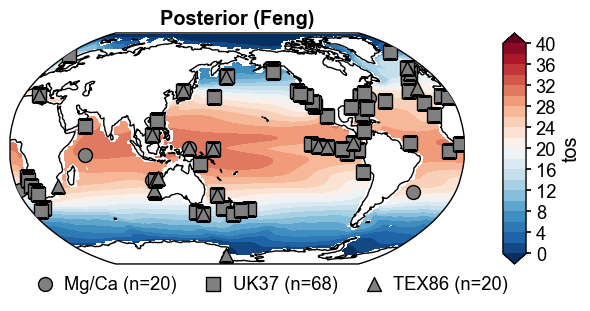

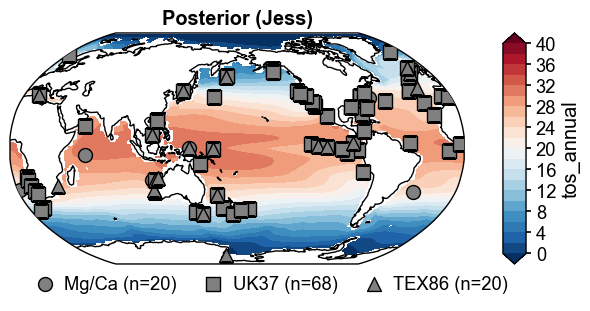

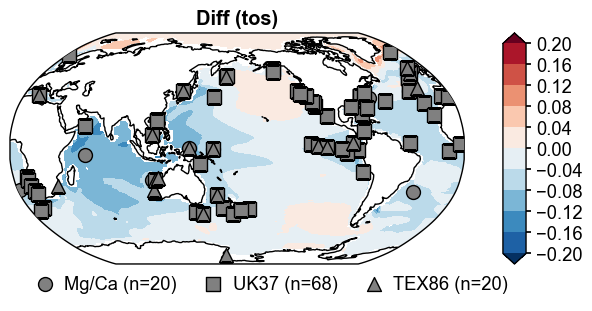

In [16]:
%%time
da_Feng = da_solver.post['tos'].mean('ens')
da_Jess = ds_Jess['tos_annual'].isel(time=1)

fig, ax = da_Feng.x.plot(
    levels=np.linspace(0, 40, 21),
    cbar_kwargs={'ticks': np.linspace(0, 40, 11)},
    cmap='RdBu_r',
    title='Posterior (Feng)',
    df_sites=obs.df[['lat', 'lon', 'type']],
    site_marker_dict={
        'Mg/Ca': 'o',
        'UK37': 's',
        'TEX86': '^',
    },
    count_site_num=True,
    lgd_kws={'bbox_to_anchor': (0, -0.2)},
)

fig, ax = da_Jess.x.plot(
    levels=np.linspace(0, 40, 21),
    cbar_kwargs={'ticks': np.linspace(0, 40, 11)},
    cmap='RdBu_r',
    title='Posterior (Jess)',
    df_sites=df[['lat', 'lon', 'type']],
    site_marker_dict={
        'Mg/Ca': 'o',
        'UK37': 's',
        'TEX86': '^',
    },
    count_site_num=True,
    lgd_kws={'bbox_to_anchor': (0, -0.2)},
)


fig, ax = (da_Feng - da_Jess).x.plot(
    levels=np.linspace(-0.2, 0.2, 11),
    cbar_kwargs={'ticks': np.linspace(-0.2, 0.2, 11)},
    cmap='RdBu_r',
    title='Diff (tos)',
    df_sites=df[['lat', 'lon', 'type']],
    site_marker_dict={
        'Mg/Ca': 'o',
        'UK37': 's',
        'TEX86': '^',
    },
    count_site_num=True,
    lgd_kws={'bbox_to_anchor': (0, -0.2)},
)

In [15]:
np.max(np.abs(da_Feng - da_Jess))

<xarray.DataArray ()> Size: 8B
array(0.14067962)
Attributes:
    Units:    Celsius